In [74]:
# Objective: 
# Predict which customers are likely to accept a personal loan offer. 

# Dataset: 
#  Bank Marketing Dataset (UCI Machine Learning Repository) 

# Instructions: 
#  Perform basic data exploration on features such as age, job, and marital status. 
#  Train a Logistic Regression or Decision Tree classifier. 

# Skills: 
#  Analyze the results to identify which customer groups are more likely to accept the offer.

# importing pandas, matplotlib, seaborn, sklearn, Label Encoder, Train Test Split, Logistic Regression, Accuracy Score, and Confusion Matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
# loading bank marketing dataset into df variable
df = pd.read_csv("bank_marketing_dataset.csv")

In [11]:
# Observing first 5 rows of dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,5,may,673,2,-1,0,unknown,yes


In [56]:
# Checking for number of categories in the dataset to applying encoding
df["poutcome"].unique()

<StringArray>
['unknown', 'other', 'failure', 'success']
Length: 4, dtype: str

Text(0, 0.5, 'Frequency')

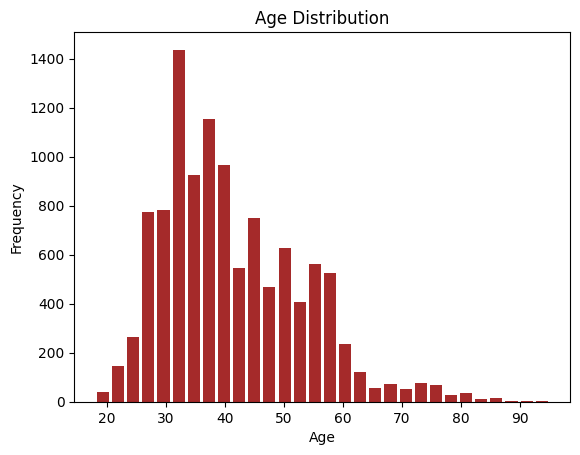

In [24]:
# Visualizing Age Dsitribtion using histogram 
plt.hist(df["age"], bins=30, rwidth=0.8, color="brown")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'admin.'),
  Text(1, 0, 'technician'),
  Text(2, 0, 'services'),
  Text(3, 0, 'management'),
  Text(4, 0, 'retired'),
  Text(5, 0, 'blue-collar'),
  Text(6, 0, 'unemployed'),
  Text(7, 0, 'entrepreneur'),
  Text(8, 0, 'housemaid'),
  Text(9, 0, 'unknown'),
  Text(10, 0, 'self-employed'),
  Text(11, 0, 'student')])

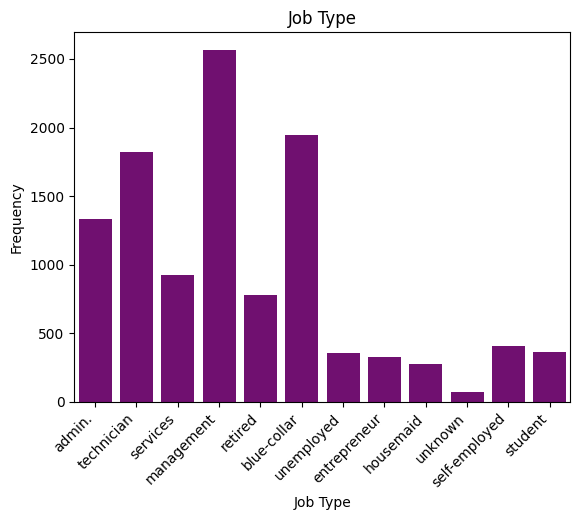

In [45]:
# Visualizing Job type Dsitribtion using countplot of seaborn library
sns.countplot(x="job", color="purple", data=df)
plt.title("Job Type")
plt.xlabel("Job Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

Text(0, 0.5, 'Frequency')

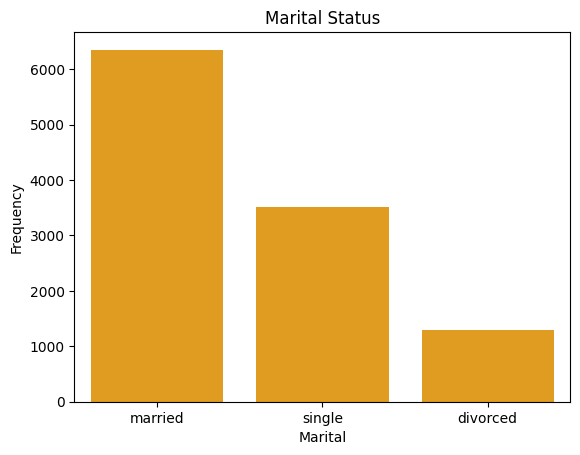

In [46]:
# Visualizing Marital Status using countplot of seaborn library
sns.countplot(x="marital", data=df, color="orange")
plt.title("Marital Status")
plt.xlabel("Marital")
plt.ylabel("Frequency")

In [59]:
# storing LabelEncoder class into a variable
le = LabelEncoder()

# applying Label Encoder class on deposit, loan, and housing variable because they are nominal(string categorical)
df["deposit"]=le.fit_transform(df["deposit"])
df["loan"]=le.fit_transform(df["loan"])
df["housing"]=le.fit_transform(df["housing"])

# applying One-Hot Encoder class on rest nominal variables
df = pd.get_dummies(df, drop_first=True)

In [60]:
# defining feature variable(X) and target variable(y)
X = df.drop("deposit", axis=1)
y = df["deposit"]

In [69]:
# scaling all X variables for model to easily understand the binary states
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [70]:
# splitting the data into Train and Test, the train and test split ratio is 0.8 means 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [71]:
# fitting Linear Regression model on the training data
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train, )

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
# Predicting the model by passing X_test as parameter and using predict function
y_pred = lr_model.predict(X_test)
print(y_pred)

[0 1 0 ... 0 1 1]


In [78]:
# finding accuracy by using accuracy_error function
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy Score: ", accuracy)

Model Accuracy Score:  0.8025078369905956


In [79]:
# finding confusion matrix by using confusion_matrix function
cm = confusion_matrix(y_test, y_pred)
print("Model Confusion Matrix: ", cm)

Model Confusion Matrix:  [[973 193]
 [248 819]]


Text(50.722222222222214, 0.5, 'Actual Deposit')

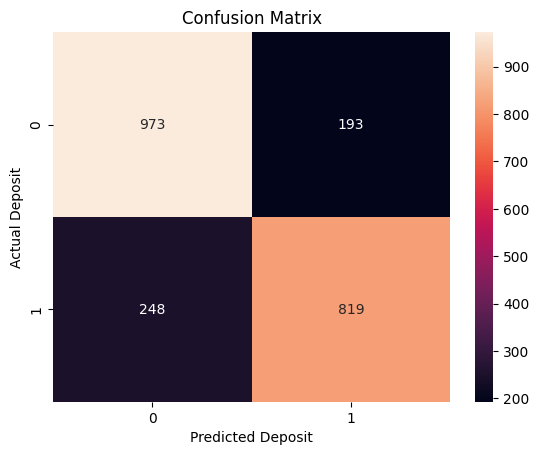

In [81]:
# visualizing the confusion matrix by using heatmap chart to easily understand the actual and predicted combinations
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Deposit")
plt.ylabel("Actual Deposit")